In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("default")


In [2]:
DATA_PATH = Path("../data/processed/train_dataset.csv")

BATTERY_ID = "B5"
TARGET_COL = "SOH"

# Change these later after inspection
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 10)


In [3]:
df = pd.read_csv(DATA_PATH)
df.head()


,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,battery_id,RUL
0,0.000000,0.588340,0.677465,0.256110,0.270841,0.419795,0.531390,0.993968,0.993968,B5,219
1,0.004016,0.556797,0.384837,0.436231,0.179901,0.827110,0.468747,0.994003,0.994003,B5,218
2,0.008032,0.561721,0.744226,0.408574,0.338137,0.388343,0.718038,0.992404,0.992404,B5,217
3,0.012048,0.451106,0.621981,0.587108,0.523626,0.345811,0.453588,0.980321,0.980321,B5,216
4,0.016064,0.352353,0.332290,0.523573,0.490199,0.662421,0.488264,0.984848,0.984848,B5,215


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Battery IDs:", df["battery_id"].unique().tolist())


Shape: (430, 11)
Columns: ['cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT', 'BCt', 'SOH', 'battery_id', 'RUL']
Battery IDs: ['B5', 'B6']


In [5]:
battery_df = df[df["battery_id"] == BATTERY_ID].copy()
battery_df = battery_df.sort_values("cycle").reset_index(drop=True)

series = battery_df[TARGET_COL].copy()
series.index = battery_df["cycle"]

battery_df.head()


,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,battery_id,RUL
0,0.000000,0.588340,0.677465,0.256110,0.270841,0.419795,0.531390,0.993968,0.993968,B5,219
1,0.004016,0.556797,0.384837,0.436231,0.179901,0.827110,0.468747,0.994003,0.994003,B5,218
2,0.008032,0.561721,0.744226,0.408574,0.338137,0.388343,0.718038,0.992404,0.992404,B5,217
3,0.012048,0.451106,0.621981,0.587108,0.523626,0.345811,0.453588,0.980321,0.980321,B5,216
4,0.016064,0.352353,0.332290,0.523573,0.490199,0.662421,0.488264,0.984848,0.984848,B5,215


In [6]:
print("Battery:", BATTERY_ID)
print("Series length:", len(series))
print(series.head())


Battery: B5
Series length: 220
cycle
0.000000    0.993968
0.004016    0.994003
0.008032    0.992404
0.012048    0.980321
0.016064    0.984848
Name: SOH, dtype: float64


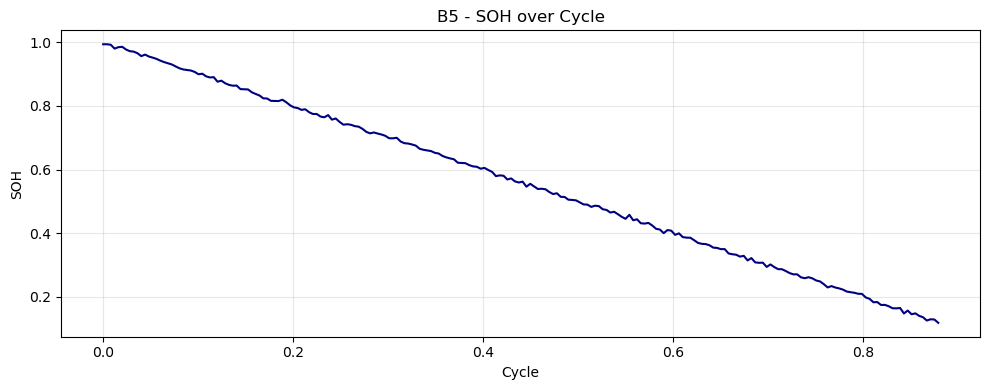

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(series.index, series.values, color="navy")
plt.title(f"{BATTERY_ID} - {TARGET_COL} over Cycle")
plt.xlabel("Cycle")
plt.ylabel(TARGET_COL)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
adf_result = adfuller(series.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

if adf_result[1] < 0.05:
    print("\nConclusion: The series is likely stationary.")
else:
    print("\nConclusion: The series is likely non-stationary.")


ADF Statistic: -0.11349036247593443
p-value: 0.9480781530681901
Critical Values:
  1%: -3.4624988216864776
  5%: -2.8756749365852587
  10%: -2.5743041549627677

Conclusion: The series is likely non-stationary.


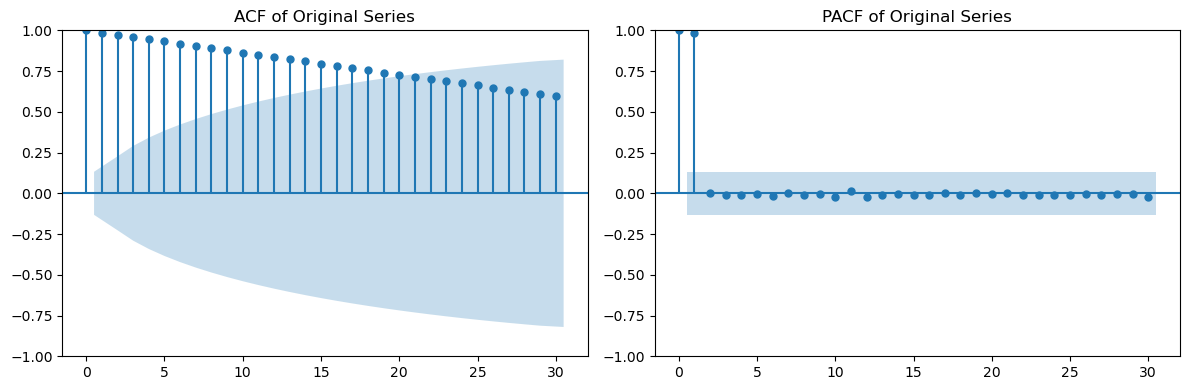

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series.dropna(), lags=30, ax=axes[0])
plot_pacf(series.dropna(), lags=30, ax=axes[1], method="ywm")
axes[0].set_title("ACF of Original Series")
axes[1].set_title("PACF of Original Series")
plt.tight_layout()
plt.show()


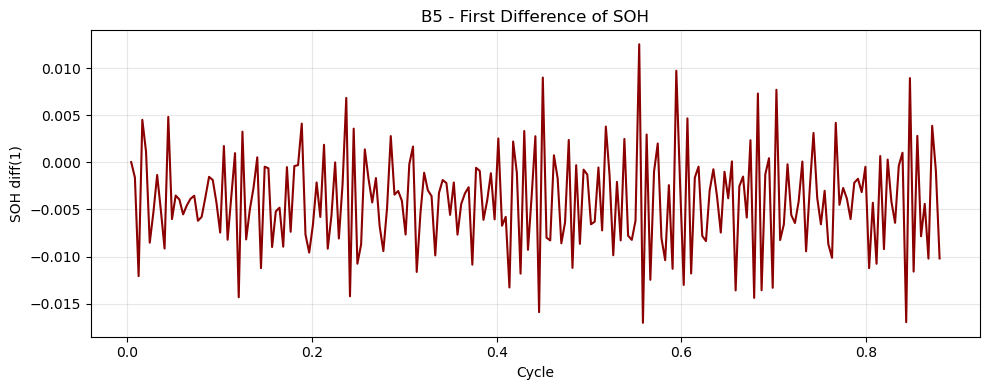

In [10]:
diff_1 = series.diff().dropna()

plt.figure(figsize=(10, 4))
plt.plot(diff_1.index, diff_1.values, color="darkred")
plt.title(f"{BATTERY_ID} - First Difference of {TARGET_COL}")
plt.xlabel("Cycle")
plt.ylabel(f"{TARGET_COL} diff(1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
adf_result_diff = adfuller(diff_1)

print("ADF Statistic after 1st difference:", adf_result_diff[0])
print("p-value after 1st difference:", adf_result_diff[1])
print("Critical Values:")
for key, value in adf_result_diff[4].items():
    print(f"  {key}: {value}")

if adf_result_diff[1] < 0.05:
    print("\nConclusion: The differenced series is likely stationary.")
else:
    print("\nConclusion: The differenced series is still likely non-stationary.")


ADF Statistic after 1st difference: -7.802770222962132
p-value after 1st difference: 7.417142720362277e-12
Critical Values:
  1%: -3.4624988216864776
  5%: -2.8756749365852587
  10%: -2.5743041549627677

Conclusion: The differenced series is likely stationary.


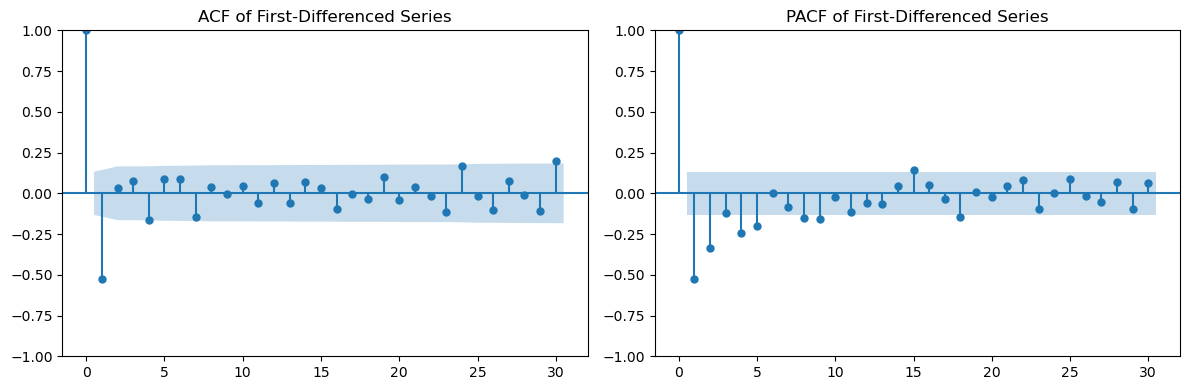

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff_1, lags=30, ax=axes[0])
plot_pacf(diff_1, lags=30, ax=axes[1], method="ywm")
axes[0].set_title("ACF of First-Differenced Series")
axes[1].set_title("PACF of First-Differenced Series")
plt.tight_layout()
plt.show()


In [13]:
# Time-based split on the SAME battery
split_idx = int(len(series) * 0.8)

train_series = series.iloc[:split_idx]
test_series = series.iloc[split_idx:]

print("Train length:", len(train_series))
print("Test length:", len(test_series))
print("Train last cycle:", train_series.index[-1])
print("Test first cycle:", test_series.index[0])


Train length: 176
Test length: 44
Train last cycle: 0.7028112449799195
Test first cycle: 0.7068273092369477


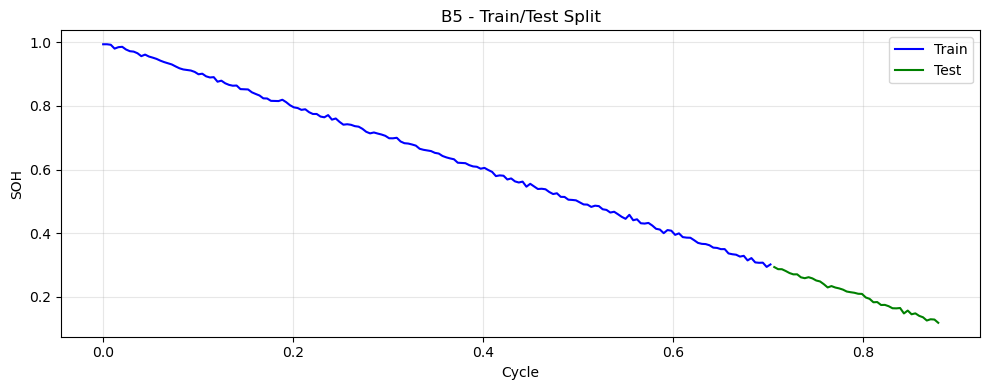

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(train_series.index, train_series.values, label="Train", color="blue")
plt.plot(test_series.index, test_series.values, label="Test", color="green")
plt.title(f"{BATTERY_ID} - Train/Test Split")
plt.xlabel("Cycle")
plt.ylabel(TARGET_COL)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
model = SARIMAX(
    train_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

fitted_model = model.fit(disp=False)
print(fitted_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                SOH   No. Observations:                  176
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 10)   Log Likelihood                 618.450
Date:                            Fri, 24 Apr 2026   AIC                          -1226.900
Time:                                    16:07:57   BIC                          -1211.432
Sample:                                         0   HQIC                         -1220.620
                                            - 176                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9993      0.004    260.223      0.000       0.992       1.007
ma.L1         -1.0001     11.229   

In [16]:
forecast = fitted_model.forecast(steps=len(test_series))
forecast.index = test_series.index

rmse = mean_squared_error(test_series, forecast, squared=False)
mae = mean_absolute_error(test_series, forecast)

print("ORDER:", ORDER)
print("SEASONAL_ORDER:", SEASONAL_ORDER)
print("RMSE:", rmse)
print("MAE:", mae)


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_series.index, train_series.values, label="Train", color="blue")
plt.plot(test_series.index, test_series.values, label="Actual Test", color="green")
plt.plot(forecast.index, forecast.values, label="Forecast", color="orange")
plt.title(f"SARIMA Forecast for {BATTERY_ID}")
plt.xlabel("Cycle")
plt.ylabel(TARGET_COL)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
results_df = pd.DataFrame({
    "cycle": test_series.index,
    "actual_soh": test_series.values,
    "forecast_soh": forecast.values,
})

results_df.head(10)


In [ ]:
candidate_configs = [
    ((0, 1, 0), (0, 0, 0, 10)),
    ((1, 1, 0), (0, 0, 1, 10)),
    ((0, 1, 1), (1, 0, 0, 10)),
    ((1, 1, 1), (1, 0, 1, 10)),
    ((2, 1, 1), (1, 0, 1, 10)),
]

rows = []

for order, seasonal_order in candidate_configs:
    try:
        model = SARIMAX(
            train_series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted = model.fit(disp=False)
        pred = fitted.forecast(steps=len(test_series))
        pred.index = test_series.index

        rmse = mean_squared_error(test_series, pred, squared=False)
        mae = mean_absolute_error(test_series, pred)

        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fitted.aic,
            "bic": fitted.bic,
            "rmse": rmse,
            "mae": mae,
        })
    except Exception as e:
        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": None,
            "bic": None,
            "rmse": None,
            "mae": None,
            "error": str(e),
        })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values("rmse", na_position="last")
